In [20]:
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import platform
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed
import pickle

system = platform.system()

if system == 'Linux':
    home = '/home/gerard/'
elif system == 'Darwin':
    home = '/Users/gerard/'
elif system == "Windows":
    home = 'C:/Users/cviko/'



try:
    sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
    from data_processing import *
    from utils import *
except:
    path2add = home + 'analysis/confocal/src'
    sys.path.append(path2add)
    from data_processing import *
    from utils import *
    from plotter import *


home = home + 'data/confocal/'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
date = '2026_06_15'
user = 'Carmina'
info = describe_acquisition( home + date + '_' + user + '/Project.lif')


══════════════════════════════════════════════════════════════
Scene 0: dec02_5x_brain3gamma_R8
══════════════════════════════════════════════════════════════
  Objective  : HC PL APO CS2    63x/1.40 OIL
  NA / n     : 1.4 / 1.518
  Voxel size : XY = 0.0226 µm/px  |  Z = 0.1307 µm/step
  Shape      : 108 × 512 × 512  (Z × Y × X)

  ────────────────────────────────────── Acquisition sequences
  Seq 1  laser(s): 488 nm + 638 nm  [simultaneous]
         pinhole  : 95.58 µm  (1.001 AU)
         det ch1  501–610 nm  Leica/ALEXA 488         em = 519 nm
         det ch2  643–788 nm  Leica/Cy5               em = 670 nm
  Seq 2  laser(s): 552 nm
         pinhole  : 95.58 µm  (1.001 AU)
         det ch2  552–802 nm  (unnamed)               em = 570 nm

  ────────────────────────────────────── Image channels (0-indexed)
  ch0  Leica/ALEXA 488         em=519 nm  σ_xy=3.45px (0.078µm) [✓]  σ_z=2.03px [✓]  → 3D
  ch1  Leica/Cy5               em=670 nm  σ_xy=4.45px (0.101µm) [✓]  σ_z=2.62px [✓]  → 3

In [3]:
loader2(date,user,False, False)

/home/gerard/data/confocal/2026_06_15_Carmina
Number of series: 12
series 0: shape = (1, 3, 108, 512, 512)
series 1: shape = (1, 3, 108, 512, 512)
series 2: shape = (1, 3, 58, 512, 512)
series 3: shape = (1, 3, 58, 512, 512)
series 4: shape = (1, 3, 58, 512, 512)
series 5: shape = (1, 3, 97, 512, 512)
series 6: shape = (1, 3, 59, 512, 512)
series 7: shape = (1, 3, 62, 512, 512)
series 8: shape = (1, 3, 101, 512, 512)
series 9: shape = (1, 3, 62, 512, 512)
series 10: shape = (1, 3, 66, 512, 512)
series 11: shape = (1, 3, 114, 512, 512)


### DECONVOLUTION :

In [4]:


path_data = date + '_' + user + '/Project.lif'
path_data_all = home + path_data #os.path.join(hom

print(path_data_all)
img = AICSImage(path_data_all)
# print(len(img.scenes))
# print(img.scenes[0])



/home/gerard/data/confocal/2026_06_15_Carmina/Project.lif


#### serial version 

In [ ]:



scenes = list(range(len(info.keys())))
#scenes = [0,1,2,3,4]
# flagged2d_gaussian_lucy = []
flagged2d_estimate_blind = []

#flagged2d_estimate_tv2 = []




## DESIRED NUMBER OF ITERATIONS:
iterations = [
      #      1,        
            2,
            # #3,
            4,
            # 5,
            #6,
            # # 7, 
            # 10, 
            # 15,
            # 20,
            #20result[bg].std() / original[bg].std()
            ]

for scene in scenes:
    img.set_scene(img.scenes[scene])
    channels = list(range(len(info[list(info.keys())[scene]]['image_channels'])))
    for channel in channels:   
        stack = img.get_image_data("ZYX", T=0, C=channel)
        for num_iter in iterations:
            print(f'--------------> iteration {num_iter} for scene {scene} channel {channel}')
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter, forced2d = True)
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d_gaussian_lucy.append(flagged)
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter,  psf_model='gibson-lanni', forced2d = True)
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d_gibson_lucy.append(flagged)
            
            #algorithm='unsupervised_wiener'
            
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter,  psf_model='estimate', forced2d = True, algorithm='blind_richardson_lucy')
            flagged = analyze_deconvolution_results(result, stack)
            flagged2d_estimate_blind.append(flagged)
            
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter,  psf_model='estimate', forced2d = True, algorithm='blind_richardson_lucy')
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d_estimate_blind.append(flagged)
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter,  psf_model='gibson-lanni', forced2d = True, algorithm='unsupervised_wiener')
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d_gibson_wiener.append(flagged)
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter, forced2d = True)
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d.append(flagged)
            

--------------> iteration 4 for scene 0 channel 0
1.001 <------------------ pinhole
PSF estimate: recovered σ_xy=3.39 px (theoretical estimate was 3.45 px)
PSF (ch0, estimate): λ=519 nm | σ_xy=0.078 µm (3.39 px) | σ_z=0.265 µm (2.03 px) → 2D-per-frame (σ_z=2.03 px, FORCED)
Blind RL recovered σ_xy: 3.34 px (theoretical estimate was 3.39 px)
2026_06_15_s0_ch0_deconv2d_psfest_blind_iter_4.tif
0.000 of inspected frames flagged
--------------> iteration 4 for scene 0 channel 1
0.7754014925373133 <------------------ pinhole
Applying pinhole factor 0.934 to PSF σ values: σ_xy 4.45 px → 4.16 px, σ_z 2.62 px → 2.45 px
PSF estimate: recovered σ_xy=4.01 px (theoretical estimate was 4.16 px)
PSF (ch1, estimate): λ=670 nm | σ_xy=0.094 µm (4.01 px) | σ_z=0.320 µm (2.45 px) → 2D-per-frame (σ_z=2.45 px, FORCED)
Blind RL recovered σ_xy: 3.87 px (theoretical estimate was 4.01 px)
2026_06_15_s0_ch1_deconv2d_psfest_blind_iter_4.tif
0.009 of inspected frames flagged
--------------> iteration 4 for scene 0 

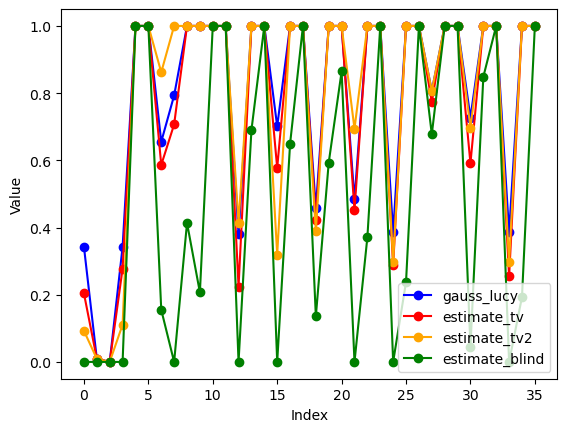

In [14]:
plt.plot(range(len(flagged2d_gaussian_lucy)), flagged2d_gaussian_lucy, 
         'o-', label='gauss_lucy', color='blue')  # 'o-' means circles with lines

plt.plot(range(len(flagged2d_estimate_tv)), flagged2d_estimate_tv, 
         'o-', label='estimate_tv', color='red')  # 'o-' means circles with lines

plt.plot(range(len(flagged2d_estimate_tv2)), flagged2d_estimate_tv2, 
         'o-', label='estimate_tv2', color='orange')  # 'o-' means circles with lines

plt.plot(range(len(flagged2d_estimate_blind)), flagged2d_estimate_blind, 
         'o-', label='estimate_blind', color='green')  # 'o-' means circles with lines

# plt.plot(range(len(flagged2d_gaussian_tv)), flagged2d_gaussian_tv, 
#          'o-', label='gauss_tv', color='orange')  # 'o-' means circles with lines

# plt.plot(range(len(flagged2d_gibson_tv)), flagged2d_gibson_tv, 
#          'o-', label='gibson_tv', color='cyan') 

# plt.plot(range(len(flagged2d_estimate_tv)), flagged2d_estimate_tv, 
#          'o-', label='estimate_tv', color='green')   





# 
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

In [19]:
# print(len([i for i in flagged2d_gaussian_lucy if i <0.5])/len(flagged2d_gaussian_lucy))
# print(len([i for i in flagged2d_estimate_tv if i <0.5])/len(flagged2d_estimate_tv))
# print(len([i for i in flagged2d_estimate_tv2 if i <0.5])/len(flagged2d_estimate_tv))
print(len([i for i in flagged2d_estimate_blind if i <0.5])/len(flagged2d_estimate_blind))

0.4444444444444444


In [29]:
print(flagged2d_gibson)

[0.3425925925925926, 0.009259259259259259, 0.0, 0.3425925925925926, 1.0, 1.0, 0.6551724137931034, 0.8448275862068966, 1.0, 1.0, 1.0, 1.0, 0.3793103448275862, 1.0, 1.0]


#### parallelized version 

In [4]:
print(f'cpus: {os.cpu_count()}')


24

In [23]:

n_jobs = os.cpu_count() - 2
print(f'n_jobs:{n_jobs}')
iterations = [
      #      1,        
            2,
            #3,
            4,
            #5,
            # 6,
            # 7, 
            # 10, 
            # 15,
            # 20,
            #20result[bg].std() / original[bg].std()
            ]

scenes = list(range(len(info.keys())))
# --- Phase 1: load all stacks sequentially (img is stateful) ---
stacks = {}
scene_channels = {}
for scene in scenes:
    img.set_scene(img.scenes[scene])
    channels = list(range(len(info[list(info.keys())[scene]]['image_channels'])))
    scene_channels[scene] = channels
    for channel in channels:
        stacks[(scene, channel)] = img.get_image_data("ZYX", T=0, C=channel)

# --- Phase 2: build flat job list ---
jobs = [
    (stacks[(scene, channel)], scene, channel, num_iter, forced2d)
    for scene in scenes
    for channel in scene_channels[scene]
    for num_iter in iterations
    for forced2d in [True]#[False, True]
]

def run_one(stack, scene, channel, num_iter, forced2d):
    # result, sigma_xy_px = deconvolve(
    #     stack, path_data_all, channel=channel, scene=scene,
    #     num_iter=num_iter, forced2d=forced2d
    # )
    result, sigma_xy_px = deconvolve(
        stack, path_data_all, channel=channel, scene=scene,
        num_iter=num_iter,  psf_model='estimate', forced2d = True, 
        algorithm='blind_richardson_lucy')
    
    flagged = analyze_deconvolution_results(result, stack)
    return (scene, channel, num_iter, forced2d, flagged)

# --- Run in parallel (threading shares imports & sys.path) ---
results = Parallel(n_jobs=n_jobs, backend='threading')(
    delayed(run_one)(*job) for job in jobs
)

# --- Reconstruct flagged lists ---
flagged3d = [r[-1] for r in results if not r[-2]]   # forced2d=False
flagged2d = [r[-1] for r in results if r[-2]]        # forced2d=True


n_jobs:14
0.7754014925373133 <------------------ pinhole
Applying pinhole factor 0.934 to PSF σ values: σ_xy 4.45 px → 4.16 px, σ_z 2.62 px → 2.45 px
1.001 <------------------ pinhole
0.911436842105263 <------------------ pinhole
Applying pinhole factor 0.974 to PSF σ values: σ_xy 3.79 px → 3.69 px, σ_z 2.23 px → 2.17 px
0.911436842105263 <------------------ pinhole
Applying pinhole factor 0.974 to PSF σ values: σ_xy 3.79 px → 3.69 px, σ_z 2.23 px → 2.17 px
0.911436842105263 <------------------ pinhole
Applying pinhole factor 0.974 to PSF σ values: σ_xy 3.79 px → 3.69 px, σ_z 2.23 px → 2.17 px
1.001 <------------------ pinhole
1.001 <------------------ pinhole
0.7754014925373133 <------------------ pinhole
Applying pinhole factor 0.934 to PSF σ values: σ_xy 4.45 px → 4.16 px, σ_z 2.62 px → 2.45 px
0.7754014925373133 <------------------ pinhole
Applying pinhole factor 0.934 to PSF σ values: σ_xy 4.45 px → 4.16 px, σ_z 2.62 px → 2.45 px
0.911436842105263 <------------------ pinhole
Apply

In [9]:
for i in range(len(flagged2d)):
    if flagged2d[i]:
        print(f'flagged2d: {flagged2d[i]}')

flagged2d: 0.3425925925925926
flagged2d: 0.009259259259259259
flagged2d: 0.3425925925925926
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.6551724137931034
flagged2d: 0.7931034482758621
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.3793103448275862
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.7010309278350515
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.4576271186440678
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.4838709677419355
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.38613861386138615
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.8064516129032258
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.7272727272727273
flagged2d: 1.0
flagged2d: 1.0
flagged2d: 0.38596491228070173
flagged2d: 1.0
flagged2d: 1.0



### TRESHOLDING



| Method   |ch0: BRP (puncta)|ch1: HSP70 (diffuse) |ch2: Mitochondria| 
| --       | --              | --                  | --              |
| Otsu     | unstable        | weak performance    | good            |
| Triangle |  **very good**  | mediocre            | good            |
| Yen      | too strict      |often underestimates | ok              |
| Li       | good            |**best of the four** | good            |






In [3]:
#thresholding(date, user, series_list, deconv_iter_list, do_plot = True )
#scenes = list(range(len(info.keys())))

#print(list(range(len(info.keys()))))

series_list = list(range(len(info.keys())))# [0]#
# series_list = [9]
# selected_series = series_list[0]
results_deconv = thresholding(date, user, series_list, [2], channel_struct=2, do_plot = False )
results_deconv_blind_iter2 = thresholding(date, user, series_list, [2], deconv_type='_deconv2d_psfest_blind_iter_', channel_struct =2, do_plot = False )
results_deconv_blind_iter4 = thresholding(date, user, series_list, [4], deconv_type='_deconv2d_psfest_blind_iter_', channel_struct =2, do_plot = False )

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
/home/gerard/data/confocal/2026_06_15_Carmina/Project.lif
Processing series 0---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_masks_95.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_deconv2d_iter_2_masks_95.tif
Channel 1************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_1/2026_06_15_s0_ch1.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_1/2026_06_15_s0_ch1_masks_95.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_1/

## store results to do not have to run the whole thing again:


In [ ]:
path_results = home + date + '_' + user + '/results_2.pkl' #'/media/data/connectome/KC/some_results/lists_results.pkl'
with open(path_results, 'wb') as f:
    pickle.dump(results, f)

## load the results:

In [4]:
path_results = home + date + '_' + user + '/results.pkl' #'/media/data/connectome/KC/some_results/lists_results.pkl'
#name_lists_results ='/media/data/connectome/KC/some_results/lists_results.pkl'
with open(path_results, 'rb') as f:
    results = pickle.load(f)


In [ ]:
print_dict_structure(results_deconv_blind_iter4)

## Understanding the colocalization metrics

To ask whether two proteins occupy the same pixels in the image, we threshold each channel to obtain a binary mask — pixels are either positive (signal present) or negative (signal absent). All three metrics below are computed within a defined region of interest (e.g. the Mushroom Body).

---

### Directional overlap fractions (binary Manders coefficients)

These answer: *of all pixels positive for protein A, what fraction are also positive for protein B?* And vice versa.

- **Fraction of A in B** = |A∩B| / |A| — "what fraction of A pixels have B signal?"
- **Fraction of B in A** = |A∩B| / |B| — "what fraction of B pixels have A signal?"

These are directional: they can be different from each other. For example, if mitochondria are large and HSP70 is a small subset that sits on them, the fraction of HSP in Mito will be high (most HSP is on mitochondria), while the fraction of Mito in HSP will be lower (mitochondria are big, and only part of their surface has HSP).

---

### Enrichment over random

The overlap fractions alone do not tell you whether the co-localization is *more than expected by chance*. If 80% of pixels in a region are Mito-positive and 70% are HSP-positive, you would expect ~56% overlap purely by random spatial overlap, regardless of any physical association.

The enrichment corrects for this:

**Enrichment = observed overlap / expected random overlap**

where the expected overlap is calculated assuming the two signals are distributed independently within the region. An enrichment of 1.0 means no association beyond chance; an enrichment of 6× means the two proteins co-localize six times more than would be predicted if they were independently distributed.

---

### Odds ratio

The odds ratio (OR) is the most statistically rigorous of the three. It asks: *how much more likely is a pixel to be B-positive if it is A-positive, compared to if it is A-negative?*

- **OR = 1**: knowing a pixel is A-positive gives no information about B — the two signals are independent
- **OR > 1**: A-positive pixels are more likely to carry B signal — positive co-localization
- **OR = 52**: an A-positive pixel is 52 times more likely to also be B-positive than an A-negative pixel

The OR is accompanied by a p-value. With microscopy images (thousands of pixels), p-values are almost always effectively zero — what matters is the **size of the OR**, not whether p < 0.05. An OR of 2 is meaningful; an OR of 900 is dramatic.

---

### Using the three metrics together

| Metric | What it tells you |
|---|---|
| Fraction A in B | How much of A is "covered" by B |
| Fraction B in A | How much of B is "covered" by A |
| Enrichment | Is co-localization above what chance would produce? |
| Odds ratio | How strongly are A and B spatially associated? |

A complete interpretation uses all three: the fractions describe the *extent* of overlap, the enrichment shows whether it is *above chance*, and the odds ratio quantifies the *strength of association* independently of how prevalent each signal is.


In [4]:
from scipy.stats import fisher_exact, spearmanr
import pandas as pd




def snr_proxy(stack, p95_thresh=None):
    """(p95 - median) / std of background (voxels <= median).

    Proxy for how far the fixed-percentile mask threshold sits above the
    background noise floor, in background-sigma units. Low values mean the
    '95th percentile' mask is not distinguishable from the tail of the
    background noise distribution.
    """
    stack = np.asarray(stack)
    median = np.median(stack)
    if p95_thresh is None:
        p95_thresh = np.percentile(stack, 95)
    bg = stack[stack <= median]
    std_bg = bg.std()
    return round((p95_thresh - median) / std_bg, 3)


# snr_rows = []
# for series in series_list:
#     name = list(info.keys())[series]
#     row = {'name': name}
#     for c_str, c_name in channels.items():
#         entry = results['s_' + str(series)]['c_' + c_str][deconv_str_mask]
#         row[f'snr_{c_name}'] = snr_proxy(entry['stack'], entry['95']['threshold'])
#     snr_rows.append(row)

# df_snr = pd.DataFrame(snr_rows)

# df = pd.read_csv(path_csv)
# df = df.merge(df_snr, on='name')

# for c in comparisons:
#     chA_name = channels[str(c[0])]
#     chB_name = channels[str(c[1])]
#     snr_col = f'snr_min_{chA_name}_{chB_name}'
#     df[snr_col] = df[[f'snr_{chA_name}', f'snr_{chB_name}']].min(axis=1)

#     for metric in ['MB_total_odds_ratio', 'MB_total_enrichment']:
#         r, p = spearmanr(df[snr_col], df[metric])
#         print(f'Spearman({snr_col}, {metric}) = {r:.3f} (p={p:.3f})')

# df.to_csv(path_csv, index=False)
# df.sort_values(list(df.filter(like='snr_min').columns)[0], ascending=False)



def compute_colocalization(results, series_list, raw=False, deconv_iter=2, export=True):
    #raw = False # <---------------------------------

    #series_list = list(range(len(info.keys())))
    
    table_results = {}
    table_results['name'] = []
    table_results['mask_HSP'] = []
    table_results['mask_mito'] = []    
    table_results['mask_BRP'] = []

    table_results['prop_MB_BRP'] = []
    table_results['prop_MB_HSP'] = []
    table_results['prop_MB_Mito'] = []

    table_results['prop_MB-HSP_in_syn'] = []
    table_results['prop_MB-Mito_in_syn'] = []


    for series in series_list:
        #print(list(info.keys())[series])
        
        
        
        channels = {
            '0':'BRP',
            '1':'HSP',
            '2':'Mito',    
        }

        comparisons = [
                    # [0,1],
                    # [0,2],
                    [1,2],
                    ]


        chA_thrsh_al = '95'# ch1,HSP
        chB_thrsh_al = '95'# ch2,Mito
        brp_thrsh_al = '95' # ch0,BRP

        table_results['name'].append(list(info.keys())[series])
        table_results['mask_HSP'].append(chA_thrsh_al)
        table_results['mask_mito'].append(chB_thrsh_al)
        table_results['mask_BRP'].append(brp_thrsh_al)
        #************************************************************
        deconv_str_mask = 'deconv_iter_'+ str(deconv_iter)
        
        MB_mask = results['s_'+str(series)]['c_2'][deconv_str_mask]['mb'].astype(bool)
        
        if raw:
            
            brp_mask = results['s_'+str(series)]['c_0']['raw'][brp_thrsh_al]['masks'].astype(bool)
            mito_mask = results['s_'+str(series)]['c_2']['raw'][chB_thrsh_al]['masks'].astype(bool)
            hsp_mask = results['s_'+str(series)]['c_1']['raw'][chA_thrsh_al]['masks'].astype(bool)
        else:

            brp_mask = results['s_'+str(series)]['c_0'][deconv_str_mask][brp_thrsh_al]['masks'].astype(bool)
            mito_mask = results['s_'+str(series)]['c_2'][deconv_str_mask][chB_thrsh_al]['masks'].astype(bool)
            hsp_mask = results['s_'+str(series)]['c_1'][deconv_str_mask][chA_thrsh_al]['masks'].astype(bool)

        SYN_mask = MB_mask & brp_mask
        NON_SYN_mask = MB_mask & ~brp_mask
        
        prop_MB_BRP = (brp_mask & MB_mask).sum()/MB_mask.sum()#((brp_mask & MB_mask).sum()/MB_mask.sum())
        prop_MB_HSP = (hsp_mask & MB_mask).sum()/MB_mask.sum()
        prop_MB_Mito = (mito_mask & MB_mask).sum()/MB_mask.sum()
        
        prop_MB_HSP_in_syn = (hsp_mask & SYN_mask).sum()/(hsp_mask & MB_mask).sum()
        prop_MB_Mito_in_syn = (mito_mask & SYN_mask).sum()/(mito_mask & MB_mask).sum()

        table_results['prop_MB_BRP'].append(float(f'{prop_MB_BRP:.3f}'))
        table_results['prop_MB_HSP'].append(float(f'{prop_MB_HSP:.3f}'))
        table_results['prop_MB_Mito'].append(float(f'{prop_MB_Mito:.3f}'))

        table_results['prop_MB-HSP_in_syn'].append(float(f'{prop_MB_HSP_in_syn:.3f}'))
        table_results['prop_MB-Mito_in_syn'].append(float(f'{prop_MB_Mito_in_syn:.3f}'))



        for c in comparisons:
            
            chA_n = c[0]
            chB_n = c[1]
            
            if raw:
                mask_chA = results['s_'+str(series)]['c_'+str(chA_n)]['raw'][chA_thrsh_al]['masks'].astype(bool)
                mask_chB = results['s_'+str(series)]['c_'+str(chB_n)]['raw'][chB_thrsh_al]['masks'].astype(bool)
            else:
                mask_chA = results['s_'+str(series)]['c_'+str(chA_n)][deconv_str_mask][chA_thrsh_al]['masks'].astype(bool)
                mask_chB = results['s_'+str(series)]['c_'+str(chB_n)][deconv_str_mask][chB_thrsh_al]['masks'].astype(bool)
                    
            
            
            masks2check = {'MB_total': MB_mask,
                        'MB_syn': SYN_mask,
                        'MB_non_syn' : NON_SYN_mask,
                        }
            
            for msk in masks2check.keys():
                #print(msk)
                MASK = masks2check[msk]
                
                
                mask_chA_MB = mask_chA & MASK
                mask_chB_MB = mask_chB & MASK
                overlap = mask_chA_MB & mask_chB_MB # |A∩B|
                
            ############
                A_and_B  = (mask_chA_MB &  mask_chB_MB).sum()
                A_not_B  = (mask_chA_MB & ~mask_chB_MB).sum()
                B_not_A  = (~mask_chA_MB & mask_chB_MB).sum()
                neither  = MASK.sum() - A_and_B - A_not_B - B_not_A  # fixed


                table = [[A_and_B, A_not_B],
                        [B_not_A, neither]]

                odds_ratio, pvalue = fisher_exact(table, alternative='greater') 

                
                
                ##############

                fraction_A_in_B = overlap.sum() / mask_chA_MB.sum()   # = |A∩B| / |A|:  "fraction of A that is B-positive"
                fraction_B_in_A = overlap.sum() / mask_chB_MB.sum()   # = |A∩B| / |B|:  "fraction of A that is B-positive"

                
                pA = mask_chA_MB.sum() / MASK.sum()
                pB = mask_chB_MB.sum() / MASK.sum()

                # Expected overlap:
                observed = overlap.sum()
                expected = pA * pB * MASK.sum()

                #print(f'observed={observed}, expected={expected:.2f}')
                #print (f'the observed enrichment is {(observed/expected):.2f} bigger than expected.')
            
                column1 = msk + '_' +f'fraction of {channels[str(chA_n)]} in {channels[str(chB_n)]}'
                column2 = msk + '_' +f'fraction of {channels[str(chB_n)]} in {channels[str(chA_n)]}'
                column3 = msk + '_' + 'odds_ratio'
                column4 = msk + '_' + 'enrichment'
                
                if column1 not in table_results.keys():
                    table_results[column1] = []
                if column2 not in table_results.keys():
                    table_results[column2] = []
                if column3 not in table_results.keys():
                    table_results[column3] = []
                if column4 not in table_results.keys(): 
                    table_results[column4] = []
                
                table_results[column1].append(float(f'{fraction_A_in_B:.3f}'))
                table_results[column2].append(float(f'{fraction_B_in_A:.3f}'))
                table_results[column3].append(float(f'{odds_ratio:.3f}'))
                table_results[column4].append(float(f'{(observed/expected):.3f}'))

    df = pd.DataFrame(table_results)

################# the following part needs to be integrated in the main loop: ineficient.
    snr_rows = []
    for series in series_list:
        name = list(info.keys())[series]
        row = {'name': name}
        for c_str, c_name in channels.items():
            if raw:
                entry = results['s_' + str(series)]['c_' + c_str]['raw']
            else:
                entry = results['s_' + str(series)]['c_' + c_str][deconv_str_mask]
            row[f'snr_{c_name}'] = snr_proxy(entry['stack'], entry['95']['threshold'])
        snr_rows.append(row)

    df_snr = pd.DataFrame(snr_rows)
    df = df.merge(df_snr, on='name')

    for c in comparisons:
        chA_name = channels[str(c[0])]
        chB_name = channels[str(c[1])]
        snr_col = f'snr_min_{chA_name}_{chB_name}'
        df[snr_col] = df[[f'snr_{chA_name}', f'snr_{chB_name}']].min(axis=1)

        for metric in ['MB_total_odds_ratio', 'MB_total_enrichment']:
            r, p = spearmanr(df[snr_col], df[metric])
            print(f'Spearman({snr_col}, {metric}) = {r:.3f} (p={p:.3f})')
    
    if export:
        if raw:
            path_csv = home + date + '_' + user + '/coloc_results_raw.csv'
        else:
            path_csv = home + date + '_' + user + '/coloc_results.csv'
        df.to_csv(path_csv, index=False)
    
    return df

In [5]:
df_deconv = compute_colocalization(results_deconv, series_list, raw=False, deconv_iter=2, export=False)
df_raw = compute_colocalization(results_deconv, series_list, raw=True, deconv_iter=2, export=False)
df_deconv_blind2 = compute_colocalization(results_deconv_blind_iter2, series_list, raw=False, deconv_iter=2, export=False)
df_deconv_blind4 = compute_colocalization(results_deconv_blind_iter4, series_list, raw=False, deconv_iter=4, export=False)


Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = 0.720 (p=0.008)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = 0.622 (p=0.031)
Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = -0.427 (p=0.167)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = -0.483 (p=0.112)
Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = -0.427 (p=0.167)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = -0.483 (p=0.112)
Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = -0.427 (p=0.167)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = -0.483 (p=0.112)


In [52]:
print(df_raw.columns)
print(df_raw['name'])


Index(['name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'snr_BRP', 'snr_HSP', 'snr_Mito',
       'snr_min_HSP_Mito'],
      dtype='str')
0           dec02_5x_brain3gamma_R8
1          dec02_5x_brain3gamma_R16
2          dec02_5x_brain4alpha_L16
3       dec02_5x_brain4alpha_L16new
4     dec02_5x_brain4alphaprime_L16
5          dec02_5x_brain4gamma_L16
6          dec02_5x_brain4alpha_R16
7     dec02_5x_brain4alphaprime_R16
8          dec02_5x_brain4gamma_R16
9          dec02_1x_brain1alpha_L16
10    

In [93]:
def df_separator(df):
    # 5x vs 1x
    keys = ['5x', '1x', '5x.alpha_', '5x.alphaprime_','5x.gamma_', '1x.alpha_', '1x.alphaprime_','1x.gamma_']
    dict_results = dict.fromkeys(keys) 
    for k in keys:
        ks = k.split('.')
        if len(ks) == 1:
            dict_results[k] = df[df['name'].str.contains(k, case=False, na=False)]
        else:
            dict_results[k] = df[
                            df['name'].str.contains(ks[0], case=False, na=False) &
                            df['name'].str.contains(ks[1], case=False, na=False)
                                                    ]
    return(dict_results)


    # df_5x =df[df['name'].str.contains('5x', case=False, na=False)]
    # df_1x = df[df['name'].str.contains('1x', case=False, na=False)]






===== df_list[0] — 5x vs 1x (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9334
  p-value     = 0.5147
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9549
  p-value     = 0.7435
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9558
  p-value     = 0.5954
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.9868
  p-value     = 0.7804
  → Data look approximately normal

Brown-Forsythe test
Statistic = 2.7650
p-value   = 0.0687
→ Variances are not significantly different

One-way ANOVA
F statistic = 2.3954
p-value     = 0.0985
→ No significant differences detected


Effect size
Eta squared (η²) = 0.2643
Effect size interpretation: large
                               Multiple Comparison of Means - Tukey HSD, FWER=0.05                               
                group1                          

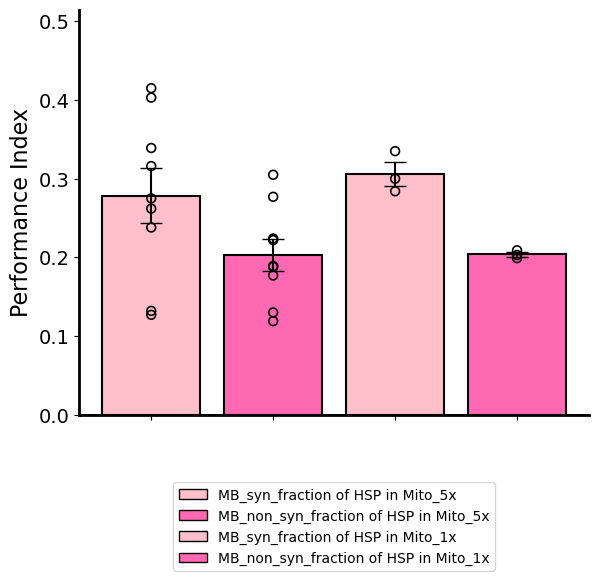


===== df_list[0] — 5x vs 1x by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9714
  p-value     = 0.6753
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.8120
  p-value     = 0.1436
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7551
  p-value     = 0.0431
  → Significant deviation from normality

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8231
  p-value     = 0.1505
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_

/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


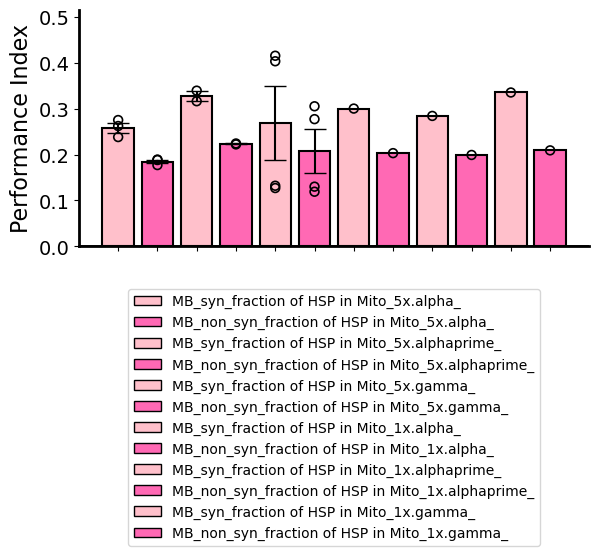


===== df_list[0] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9334
  p-value     = 0.5147
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9549
  p-value     = 0.7435
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.9046
p-value   = 0.1865
→ Variances are not significantly different

One-way ANOVA
F statistic = 3.5108
p-value     = 0.0794
→ No significant differences detected


Effect size
Eta squared (η²) = 0.1799
Effect size interpretation: large
                             Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
                group1                              group2              meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito_5x MB_syn_fraction of HSP in Mito_

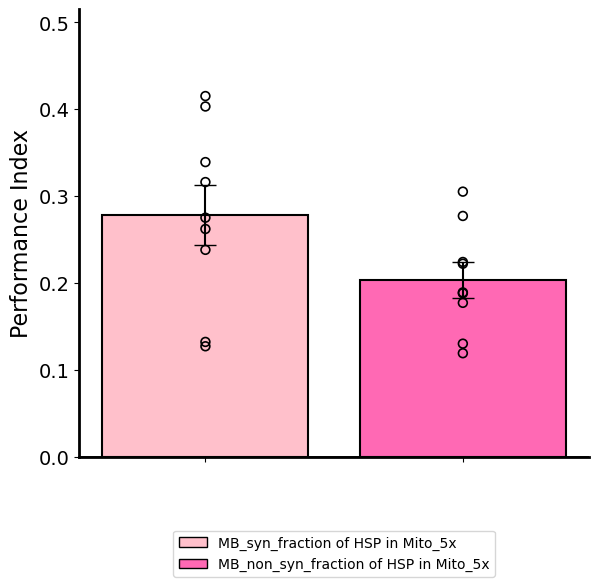


===== df_list[0] — 1x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9558
  p-value     = 0.5954
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.9868
  p-value     = 0.7804
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.7713
p-value   = 0.2540
→ Variances are not significantly different

One-way ANOVA
F statistic = 44.8106
p-value     = 0.0026
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.9181
Effect size interpretation: large
                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
                group1                              group2              meandiff p-adj  lower  upper  reject
------------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito_1x MB_syn_fraction of HSP i

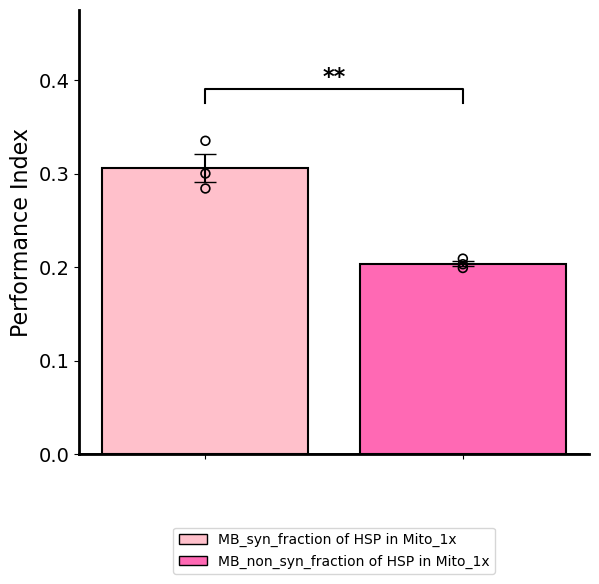


===== df_list[0] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9714
  p-value     = 0.6753
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.8120
  p-value     = 0.1436
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7551
  p-value     = 0.0431
  → Significant deviation from normality

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8231
  p-value     = 0.1505
  → Data look approximately normal

Brown-Forsythe test
Statistic = 133.5660
p-value   = 0.0000
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_5x.alpha_, mean: 0.25833333333333336, sem: 0.010837178804672581
group: MB_

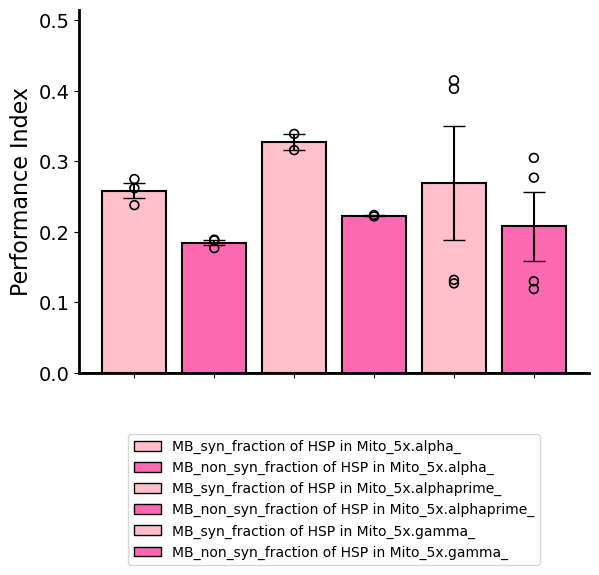


===== df_list[0] — 1x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_1x.alphaprime_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alphaprime_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_1x.gamma_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.gamma_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

Brown-Forsythe test
Statistic = nan
p-value   = nan
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_1x.alpha_, mean: 0.3, sem: nan
group: MB_non_syn_fraction of HSP in Mito_1x.alpha_, mean: 0.203, sem: nan
group: MB_syn_fraction of HSP in Mito_1x.alphaprime_, mean: 0.284, sem: nan
gr

/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


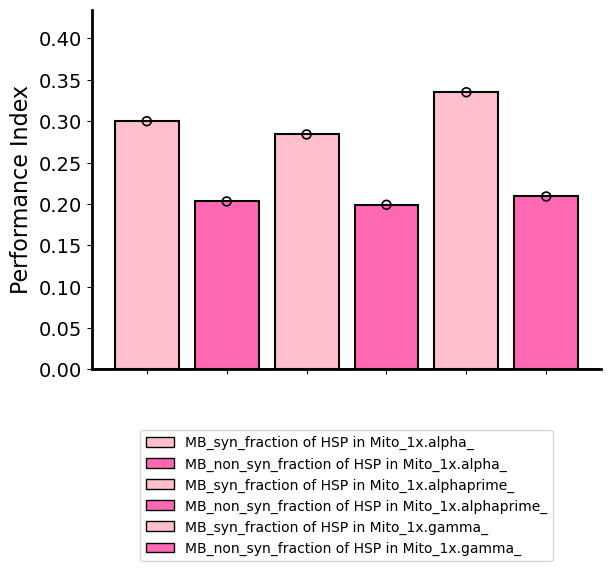


===== df_list[1] — 5x vs 1x (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9045
  p-value     = 0.2790
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.7939
  p-value     = 0.0174
  → Significant deviation from normality

MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9293
  p-value     = 0.4860
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.9508
  p-value     = 0.5729
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.2609
p-value   = 0.3146
→ Variances are not significantly different

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.6094444444444445, sem: 0.07019993493015168
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.5591111111111111, sem: 0.08423189624886175
group: MB_syn_fraction of HSP in Mito_1x, mean: 0.818, sem: 0.04701418225741392
group: MB_non_syn_fraction of HSP in Mito_1x, mean: 0.

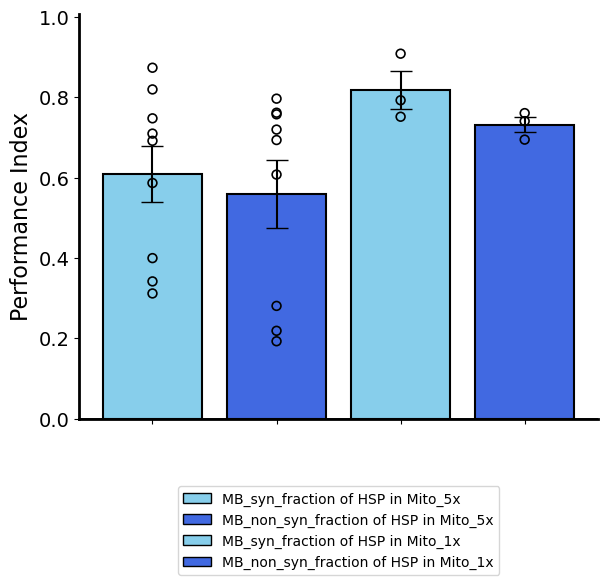


===== df_list[1] — 5x vs 1x by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9536
  p-value     = 0.5855
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9007
  p-value     = 0.3879
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8256
  p-value     = 0.1566
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8085
  p-value     = 0.1183
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fr

/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


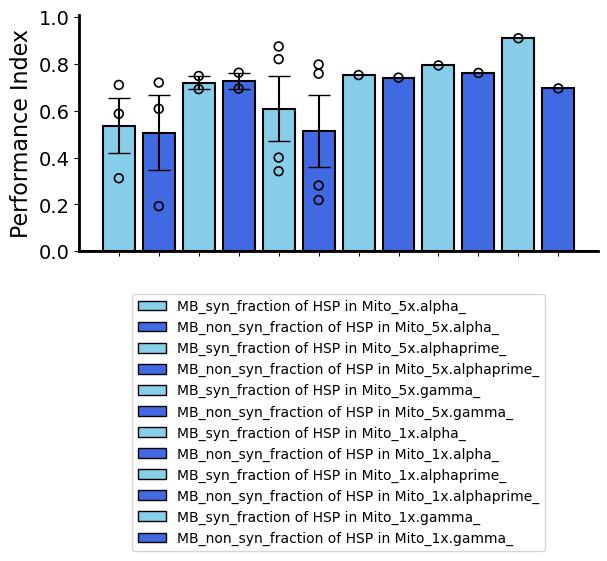


===== df_list[1] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9045
  p-value     = 0.2790
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.7939
  p-value     = 0.0174
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 0.0896
p-value   = 0.7685
→ Variances are not significantly different

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.6094444444444445, sem: 0.07019993493015168
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.5591111111111111, sem: 0.08423189624886175


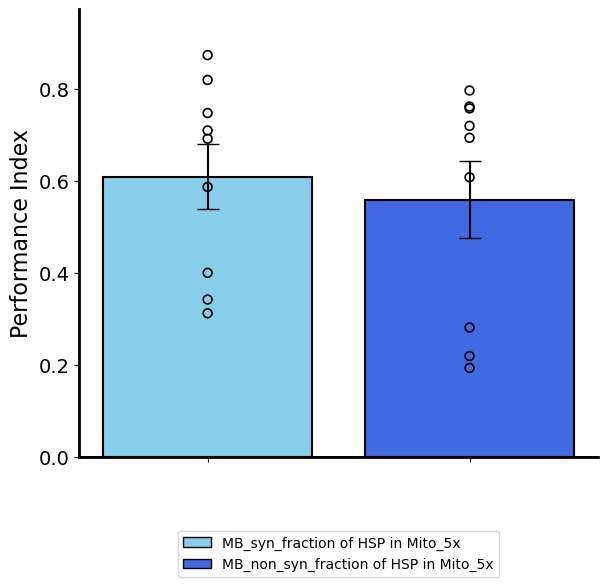


===== df_list[1] — 1x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9293
  p-value     = 0.4860
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.9508
  p-value     = 0.5729
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.6914
p-value   = 0.4524
→ Variances are not significantly different

One-way ANOVA
F statistic = 2.8312
p-value     = 0.1677
→ No significant differences detected


Effect size
Eta squared (η²) = 0.4145
Effect size interpretation: large
                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
                group1                              group2              meandiff p-adj   lower  upper reject
------------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito_1x MB_syn_fraction of HSP in Mito_1x 

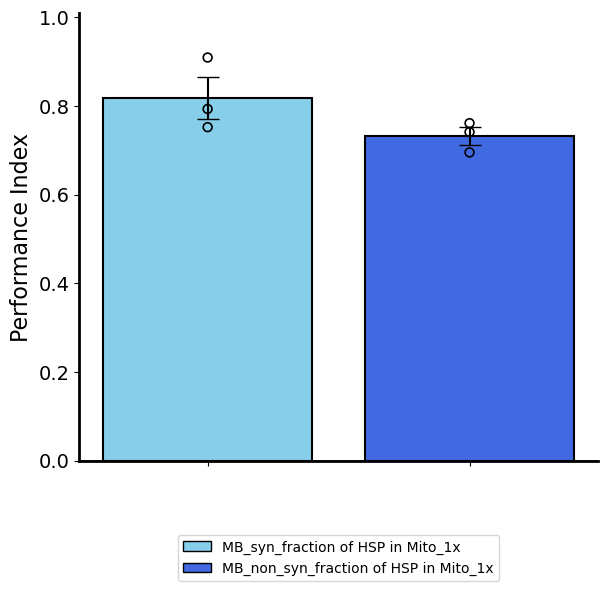


===== df_list[1] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9536
  p-value     = 0.5855
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9007
  p-value     = 0.3879
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8256
  p-value     = 0.1566
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8085
  p-value     = 0.1183
  → Data look approximately normal

Brown-Forsythe test
Statistic = 2.3849
p-value   = 0.1009
→ Variances are not significantly different

One-way ANOVA
F statistic = 0.4000
p-value     = 0.8396
→ No significant differences detected


Effect size
E

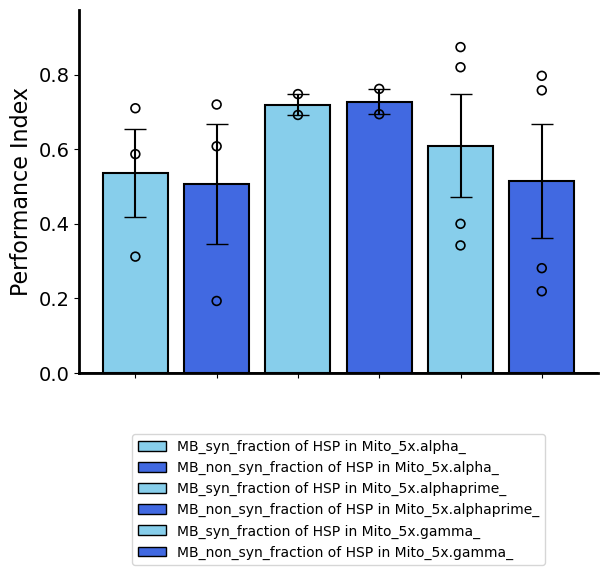


===== df_list[1] — 1x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_1x.alphaprime_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alphaprime_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_1x.gamma_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.gamma_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

Brown-Forsythe test
Statistic = nan
p-value   = nan
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_1x.alpha_, mean: 0.752, sem: nan
group: MB_non_syn_fraction of HSP in Mito_1x.alpha_, mean: 0.741, sem: nan
group: MB_syn_fraction of HSP in Mito_1x.alphaprime_, mean: 0.793, sem: nan


/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


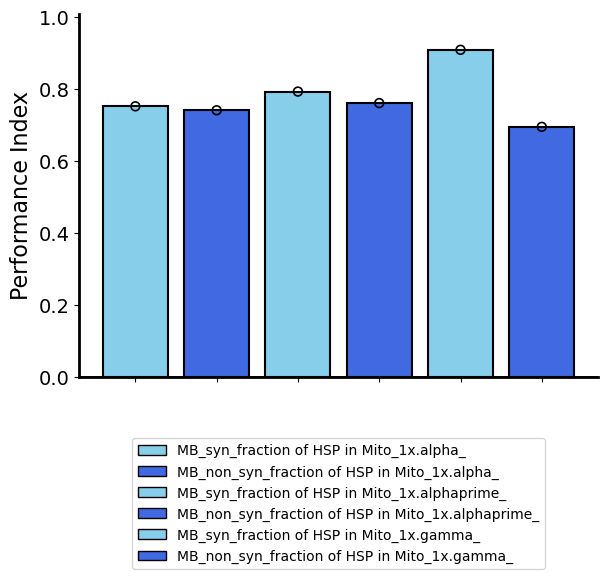


===== df_list[2] — 5x vs 1x (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9169
  p-value     = 0.3675
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9706
  p-value     = 0.9001
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.8821
  p-value     = 0.3305
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.9231
  p-value     = 0.4633
  → Data look approximately normal

Brown-Forsythe test
Statistic = 3.6867
p-value   = 0.0291
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.27222222222222225, sem: 0.03112554228790318
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.2062222222222222, sem: 0.020680625512903093
group: MB_syn_fraction of HSP in Mito_1x, mean: 0.32666666666666666, sem: 0.018442101591497406
group: MB_non_syn_fraction of HSP in Mito_1x, mean: 0.

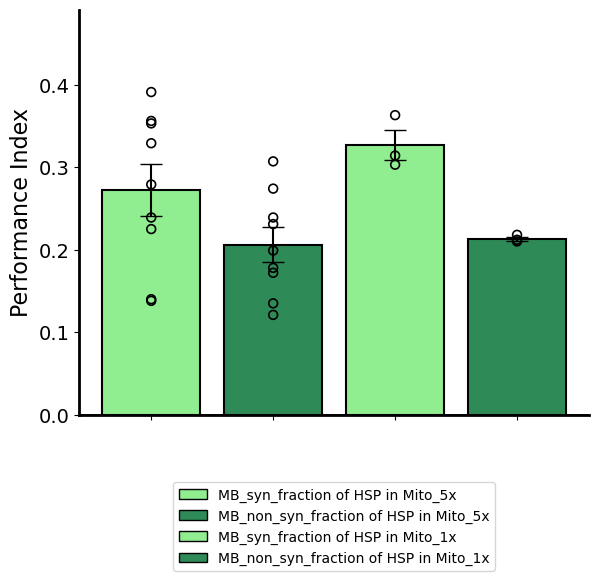


===== df_list[2] — 5x vs 1x by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9283
  p-value     = 0.4822
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9067
  p-value     = 0.4072
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7916
  p-value     = 0.0880
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8424
  p-value     = 0.2026
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fr

/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


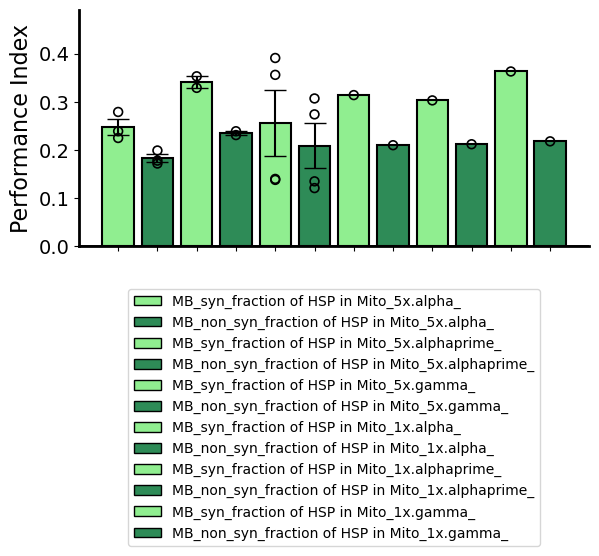


===== df_list[2] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9169
  p-value     = 0.3675
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9706
  p-value     = 0.9001
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.9290
p-value   = 0.1839
→ Variances are not significantly different

One-way ANOVA
F statistic = 3.1193
p-value     = 0.0964
→ No significant differences detected


Effect size
Eta squared (η²) = 0.1631
Effect size interpretation: large
                             Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
                group1                              group2              meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito_5x MB_syn_fraction of HSP in Mito_

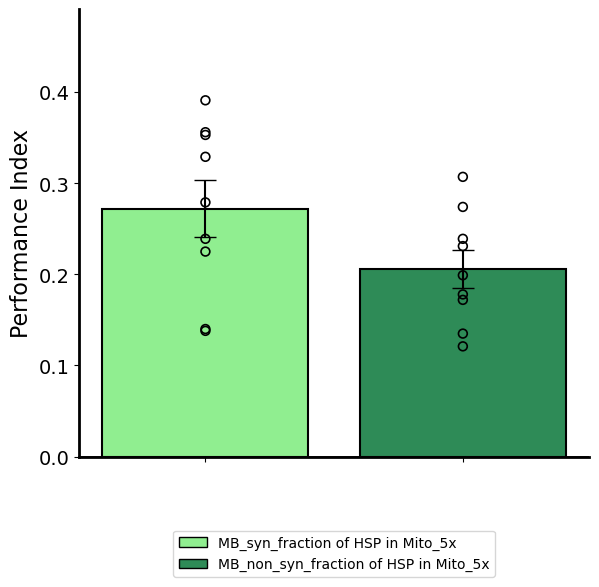


===== df_list[2] — 1x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.8821
  p-value     = 0.3305
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.9231
  p-value     = 0.4633
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.3446
p-value   = 0.3107
→ Variances are not significantly different

One-way ANOVA
F statistic = 37.1346
p-value     = 0.0037
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.9028
Effect size interpretation: large
                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                            
                group1                              group2              meandiff p-adj  lower  upper reject
-----------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito_1x MB_syn_fraction of HSP in M

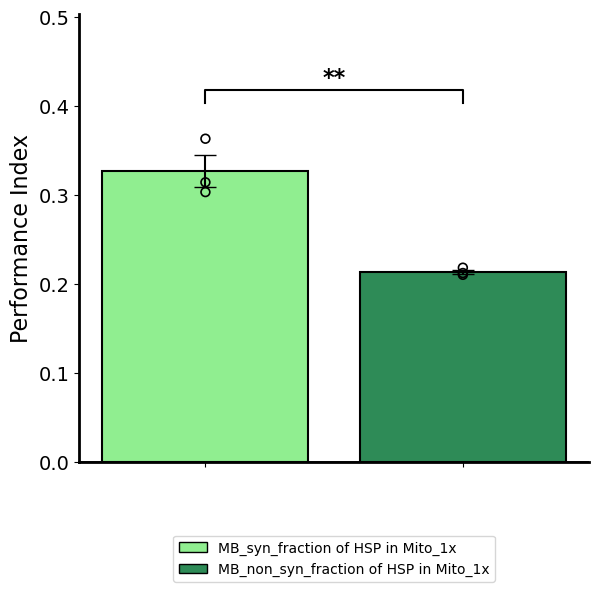


===== df_list[2] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9283
  p-value     = 0.4822
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9067
  p-value     = 0.4072
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7916
  p-value     = 0.0880
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8424
  p-value     = 0.2026
  → Data look approximately normal

Brown-Forsythe test
Statistic = 33.3703
p-value   = 0.0000
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_5x.alpha_, mean: 0.24766666666666667, sem: 0.016179548132682138
group: MB_non_syn

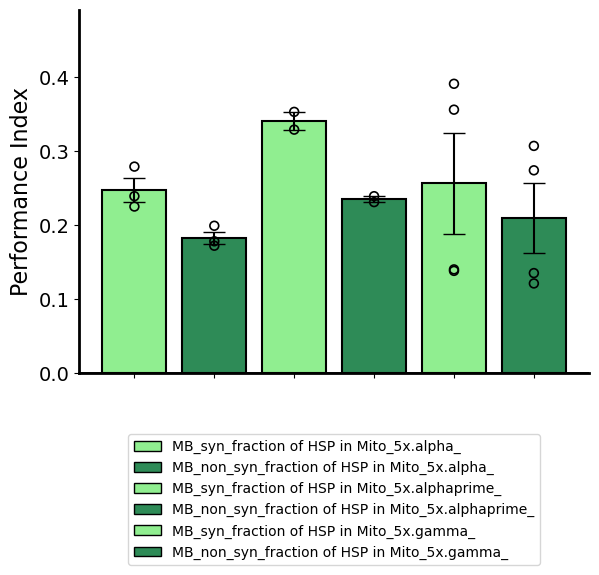


===== df_list[2] — 1x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_1x.alphaprime_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alphaprime_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_1x.gamma_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.gamma_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

Brown-Forsythe test
Statistic = nan
p-value   = nan
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_1x.alpha_, mean: 0.314, sem: nan
group: MB_non_syn_fraction of HSP in Mito_1x.alpha_, mean: 0.21, sem: nan
group: MB_syn_fraction of HSP in Mito_1x.alphaprime_, mean: 0.303, sem: nan
g

/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


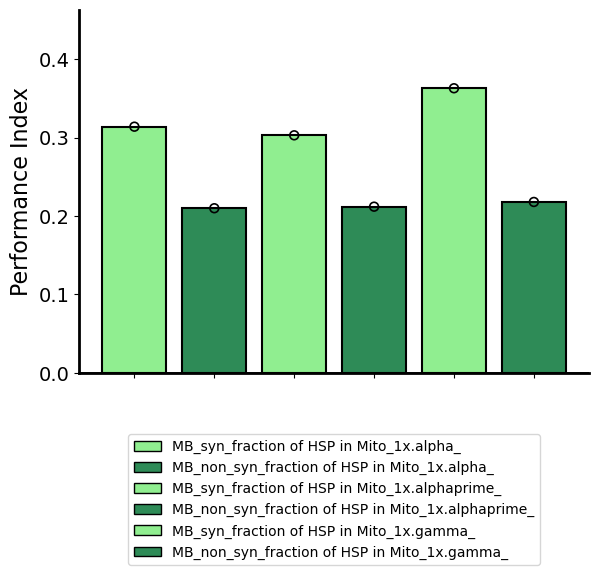


===== df_list[3] — 5x vs 1x (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9407
  p-value     = 0.5891
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9709
  p-value     = 0.9020
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9255
  p-value     = 0.4719
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.9932
  p-value     = 0.8428
  → Data look approximately normal

Brown-Forsythe test
Statistic = 3.6090
p-value   = 0.0312
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.3057777777777778, sem: 0.038880792808052615
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.2068888888888889, sem: 0.020872925342310767
group: MB_syn_fraction of HSP in Mito_1x, mean: 0.33466666666666667, sem: 0.01770436229985267
group: MB_non_syn_fraction of HSP in Mito_1x, mean: 0.2

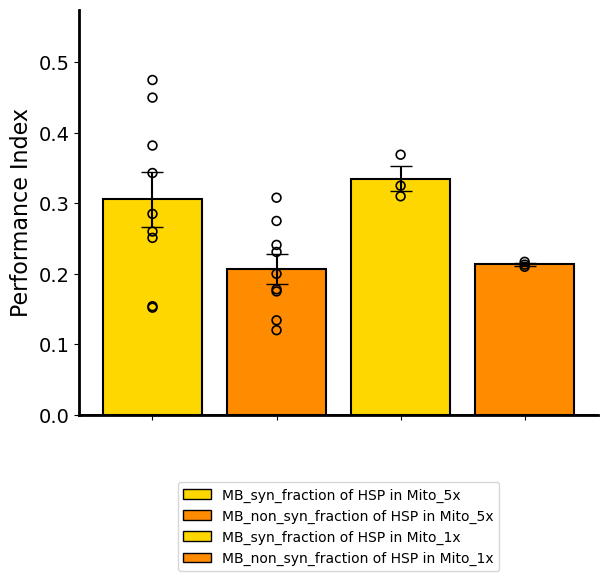


===== df_list[3] — 5x vs 1x by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9313
  p-value     = 0.4933
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.8386
  p-value     = 0.2103
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7654
  p-value     = 0.0533
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8412
  p-value     = 0.1991
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fr

/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


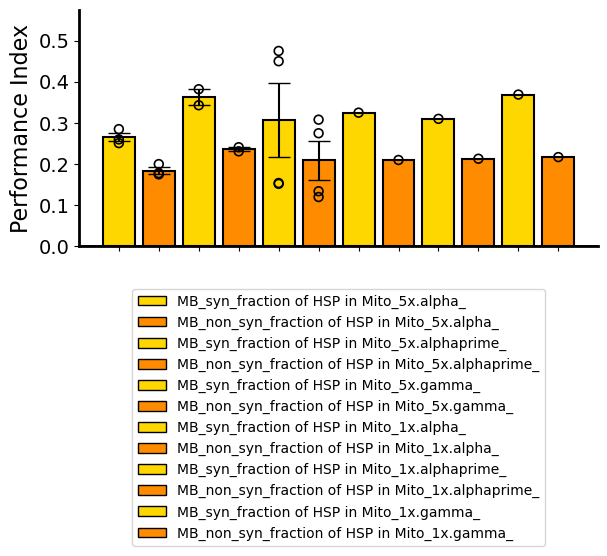


===== df_list[3] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9407
  p-value     = 0.5891
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9709
  p-value     = 0.9020
  → Data look approximately normal

Brown-Forsythe test
Statistic = 2.9197
p-value   = 0.1068
→ Variances are not significantly different

One-way ANOVA
F statistic = 5.0216
p-value     = 0.0396
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.2389
Effect size interpretation: large
                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
                group1                              group2              meandiff p-adj  lower  upper  reject
------------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito_5x MB_syn_fraction of HSP in

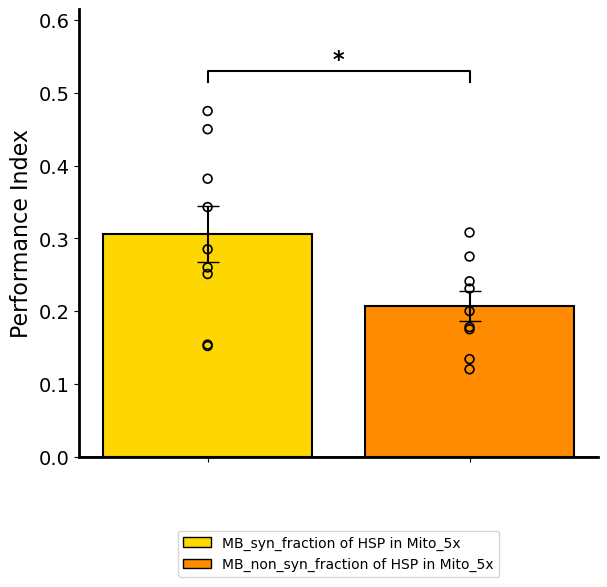


===== df_list[3] — 1x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9255
  p-value     = 0.4719
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.9932
  p-value     = 0.8428
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.7860
p-value   = 0.2524
→ Variances are not significantly different

One-way ANOVA
F statistic = 46.3597
p-value     = 0.0024
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.9206
Effect size interpretation: large
                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
                group1                              group2              meandiff p-adj  lower  upper  reject
------------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito_1x MB_syn_fraction of HSP i

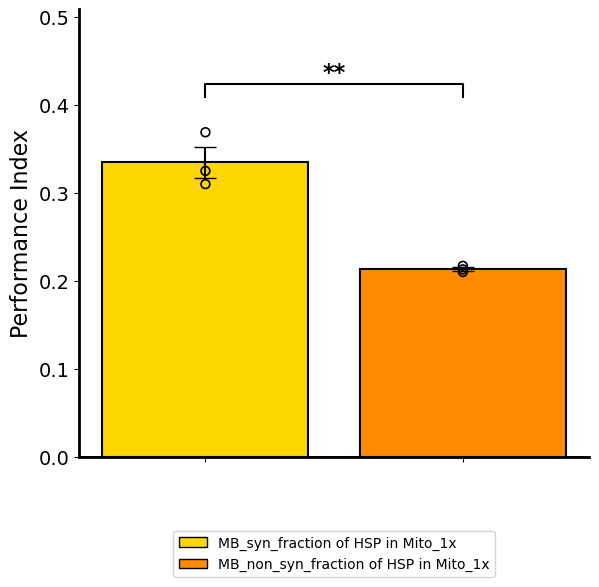


===== df_list[3] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.9313
  p-value     = 0.4933
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.8386
  p-value     = 0.2103
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7654
  p-value     = 0.0533
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8412
  p-value     = 0.1991
  → Data look approximately normal

Brown-Forsythe test
Statistic = 83.7761
p-value   = 0.0000
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_5x.alpha_, mean: 0.26533333333333337, sem: 0.010170764201594896
group: MB_non_syn

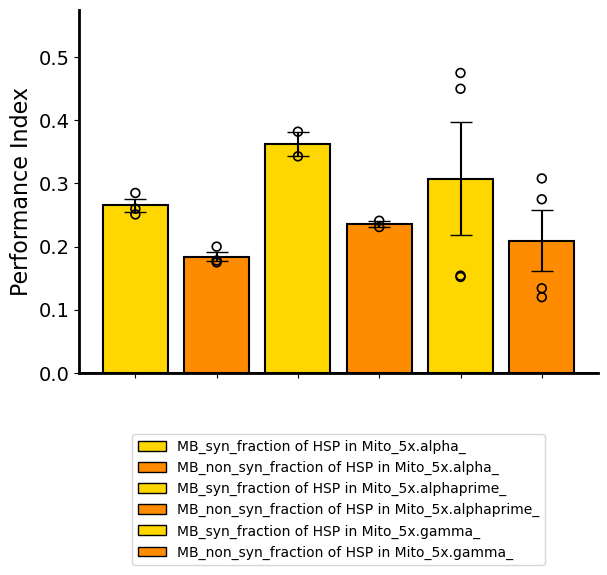


===== df_list[3] — 1x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alpha_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_1x.alphaprime_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.alphaprime_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_1x.gamma_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_1x.gamma_
  Skipped: only 1 sample(s) (need >= 3 for Shapiro-Wilk)

Brown-Forsythe test
Statistic = nan
p-value   = nan
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_1x.alpha_, mean: 0.325, sem: nan
group: MB_non_syn_fraction of HSP in Mito_1x.alpha_, mean: 0.21, sem: nan
group: MB_syn_fraction of HSP in Mito_1x.alphaprime_, mean: 0.31, sem: nan
gr

/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


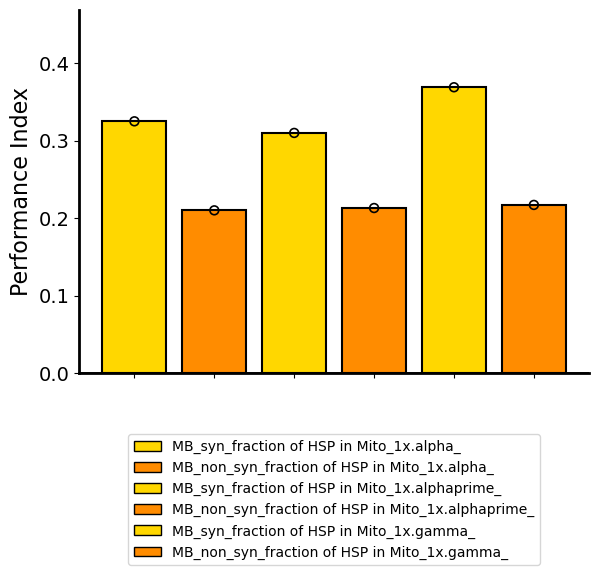

In [128]:

colmns2plot = ['MB_syn_fraction of HSP in Mito','MB_non_syn_fraction of HSP in Mito']
#colmns2plot = ['prop_MB-HSP_in_syn']
df_list = [
        df_raw,
        df_deconv,
        df_deconv_blind2, 
        df_deconv_blind4,
         ]
colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]


# '5x'/'1x' are pooled totals; the six '.'-keys are per-subregion breakdowns of the
# SAME rows (e.g. '5x.alpha_' rows are a subset of '5x' rows). Mixing pooled and
# subregion groups in one fast_plotter call would run ANOVA/Tukey on non-independent
# groups, so each combination below is plotted separately.
plot_configs = [
    ("5x vs 1x (pooled, all regions combined)", ['5x', '1x']),
    ("5x vs 1x by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_',
                                '1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
    ("5x only (pooled, all regions combined)", ['5x']),
    ("1x only (pooled, all regions combined)", ['1x']),
    ("5x only by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_']),
    ("1x only by subregion", ['1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
]

for j,df in enumerate(df_list):
    df_dict = df_separator(df)

    for title, key_group in plot_configs:
        col_data = {}
        new_col_list = []
        for k in key_group:
            df_k = df_dict[k]
            for col in colmns2plot:
                new_col = f"{col}_{k}"
                new_col_list.append(new_col)
                # reset_index: each key's rows keep their original df index (disjoint
                # across keys), so assigning straight into a DataFrame would align on
                # that index and turn every group but the first into all-NaN columns.
                col_data[new_col] = df_k[col].reset_index(drop=True)
        all_df = pd.concat(col_data, axis=1)

        print(f"\n===== df_list[{j}] — {title} =====")

        # one color per column-type in colmns2plot, repeated once per key in key_group
        # (works for any combination of len(colmns2plot)/len(key_group), unlike a
        # fixed /2 divisor which breaks when colmns2plot has an odd length or 1 entry)
        bar_color = colors[j][:len(colmns2plot)] * len(key_group)
        fast_plotter(new_col_list, df= all_df, bar_color=bar_color,  quietStats=False, figsize=(6,6), legend=True)


In [101]:
colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]
k2 = colors[0]*2
print(k2)

['pink', 'hotpink', 'pink', 'hotpink']


In [ ]:
df_raw_5x =df_raw[df_raw['name'].str.contains('5x', case=False, na=False)]
df_raw_1x = df_raw[df_raw['name'].str.contains('1x', case=False, na=False)]
assert len(df_raw_5x) + len(df_raw_1x) == len(df_raw), "some rows match both or neither pattern"
# by regions
df_raw_5x_alpha = df_raw[df_raw['name'].str.contains('alpha_prime', case=False, na=False)]
df_raw_5x_alpha_prime = df_raw[df_raw['alphaprime_'].str.contains('5x', case=False, na=False)]


df_deconv_5x =df_deconv[df_deconv['name'].str.contains('5x', case=False, na=False)]
df_deconv_1x = df_deconv[df_deconv['name'].str.contains('1x', case=False, na=False)]
assert len(df_deconv_5x) + len(df_deconv_1x) == len(df_deconv), "some rows match both or neither pattern"

df_deconv_blind2_5x =df_deconv_blind2[df_deconv_blind2['name'].str.contains('5x', case=False, na=False)]
df_deconv_blind2_1x = df_deconv_blind2[df_deconv_blind2['name'].str.contains('1x', case=False, na=False)]
assert len(df_deconv_blind2_5x) + len(df_deconv_blind2_1x) == len(df_deconv_blind2), "some rows match both or neither pattern"

df_deconv_blind4_5x =df_deconv_blind4[df_deconv_blind4['name'].str.contains('5x', case=False, na=False)]
df_deconv_blind4_1x = df_deconv_blind4[df_deconv_blind4['name'].str.contains('1x', case=False, na=False)]
assert len(df_deconv_blind4_5x) + len(df_deconv_blind4_1x) == len(df_deconv_blind4), "some rows match both or neither pattern"



In [7]:
def easy_plotter(column2plot):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(df_raw[column2plot])), df_raw[column2plot], label='raw', marker='o', color='black')
    #plt.plot(range(len(df_deconv[column2plot])), df_deconv[column2plot], label='deconv', marker='o', color='blue')
    plt.plot(range(len(df_deconv_blind2[column2plot])), df_deconv_blind2[column2plot], label='deconv_blind2', marker='o', color='green')
    plt.plot(range(len(df_deconv_blind4[column2plot])), df_deconv_blind4[column2plot], label='deconv_blind4', marker='o', color='orange')
    plt.xlabel('series')
    plt.ylabel(column2plot)
    plt.legend()
    plt.show()


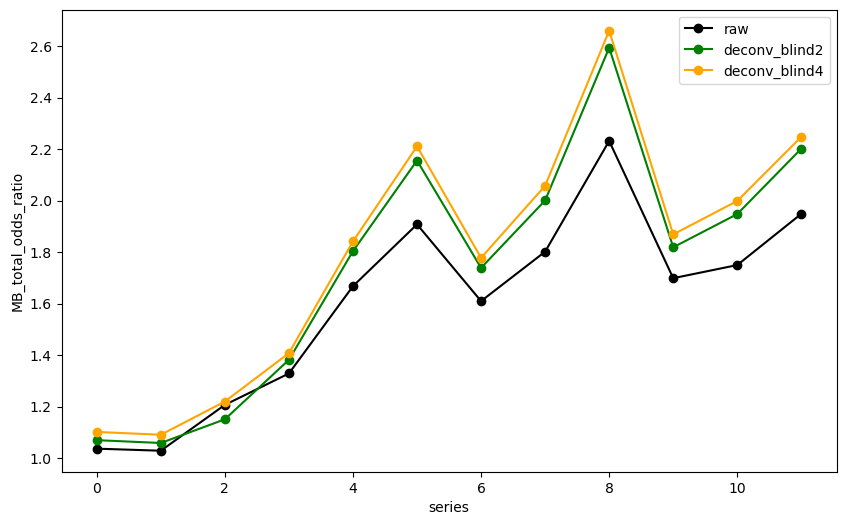

In [8]:
# easy_plotter('snr_BRP')
# easy_plotter('snr_HSP')
# easy_plotter('snr_Mito')
easy_plotter('MB_total_odds_ratio')





---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9334
  p-value     = 0.5147
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.9549
  p-value     = 0.7435
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.9046
p-value   = 0.1865
→ Variances are not significantly different

One-way ANOVA
F statistic = 3.5108
p-value     = 0.0794
→ No significant differences detected


Effect size
Eta squared (η²) = 0.1799
Effect size interpretation: large
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
              group1                           group2             meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito MB_syn_fraction of HSP in Mito   0.0751 0.0794 -0.0099 0.1601  False
------------------------------------------------------

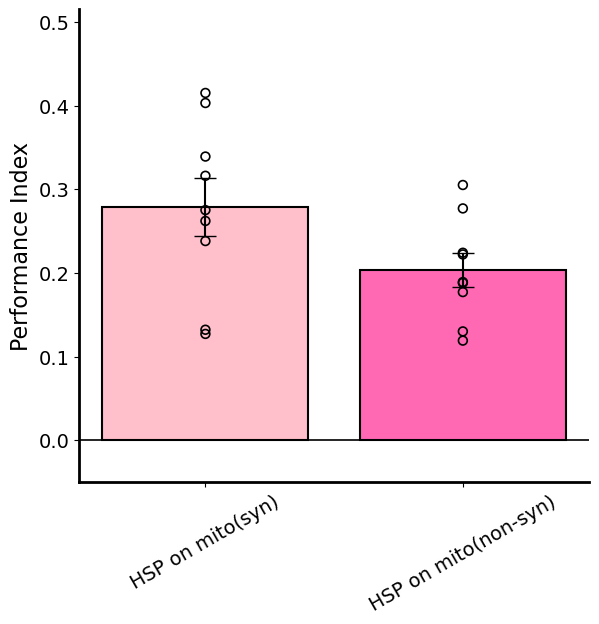


---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9045
  p-value     = 0.2790
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.7939
  p-value     = 0.0174
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 0.0896
p-value   = 0.7685
→ Variances are not significantly different

group: HSP on mito(syn), mean: 0.6094444444444445, sem: 0.07019993493015168
group: HSP on mito(non-syn), mean: 0.5591111111111111, sem: 0.08423189624886175


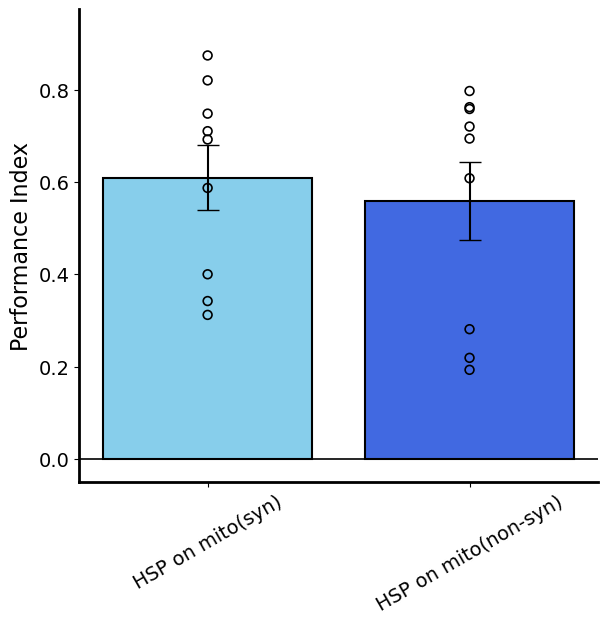


---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9169
  p-value     = 0.3675
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.9706
  p-value     = 0.9001
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.9290
p-value   = 0.1839
→ Variances are not significantly different

One-way ANOVA
F statistic = 3.1193
p-value     = 0.0964
→ No significant differences detected


Effect size
Eta squared (η²) = 0.1631
Effect size interpretation: large
                          Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
              group1                           group2             meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito MB_syn_fraction of HSP in Mito    0.066 0.0964 -0.0132 0.1452  False
------------------------------------------------------

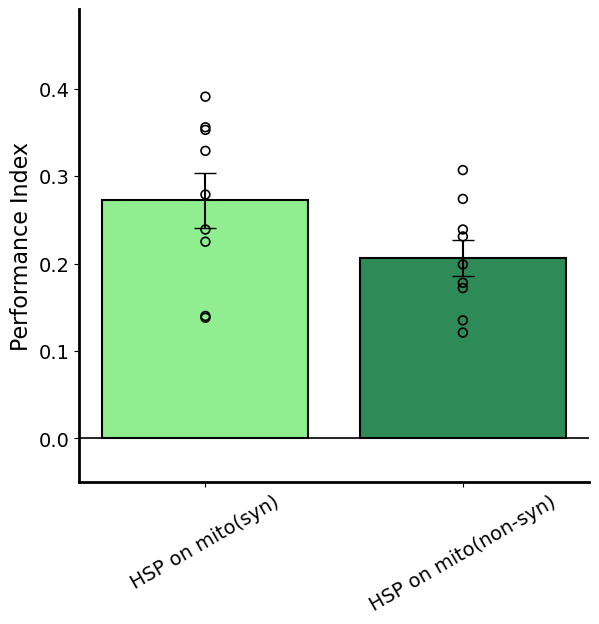


---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9407
  p-value     = 0.5891
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.9709
  p-value     = 0.9020
  → Data look approximately normal

Brown-Forsythe test
Statistic = 2.9197
p-value   = 0.1068
→ Variances are not significantly different

One-way ANOVA
F statistic = 5.0216
p-value     = 0.0396
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.2389
Effect size interpretation: large
                         Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
              group1                           group2             meandiff p-adj  lower  upper  reject
------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito MB_syn_fraction of HSP in Mito   0.0989 0.0396 0.0053 0.1924   True
-------------------------------------------------

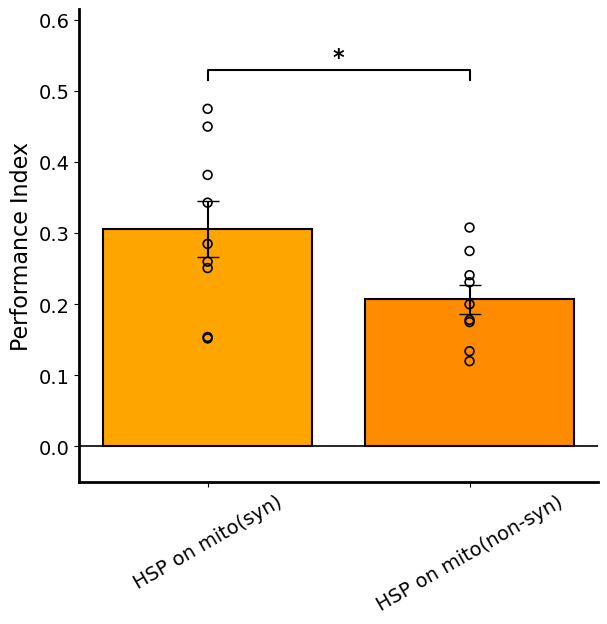

In [51]:
fast_plotter(['MB_syn_fraction of HSP in Mito','MB_non_syn_fraction of HSP in Mito'], df= df_raw_5x, bar_color=["pink","hotpink"], labels=['HSP on mito(syn)','HSP on mito(non-syn)'] )
fast_plotter(['MB_syn_fraction of HSP in Mito','MB_non_syn_fraction of HSP in Mito'], df= df_deconv_5x, bar_color=["skyblue","royalblue"], labels=['HSP on mito(syn)','HSP on mito(non-syn)'] )
fast_plotter(['MB_syn_fraction of HSP in Mito','MB_non_syn_fraction of HSP in Mito'], df= df_deconv_blind2_5x, bar_color=["lightgreen","seagreen"], labels=['HSP on mito(syn)','HSP on mito(non-syn)'] )
fast_plotter(['MB_syn_fraction of HSP in Mito','MB_non_syn_fraction of HSP in Mito'], df= df_deconv_blind4_5x, bar_color=["orange","darkorange"], labels=['HSP on mito(syn)','HSP on mito(non-syn)'] )


---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9316
  p-value     = 0.3971
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.9465
  p-value     = 0.5866
  → Data look approximately normal

Brown-Forsythe test
Statistic = 2.2082
p-value   = 0.1515
→ Variances are not significantly different

One-way ANOVA
F statistic = 7.4681
p-value     = 0.0121
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.2534
Effect size interpretation: large
                         Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
              group1                           group2             meandiff p-adj  lower  upper  reject
------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito MB_syn_fraction of HSP in Mito    0.082 0.0121 0.0198 0.1442   True
-------------------------------------------------

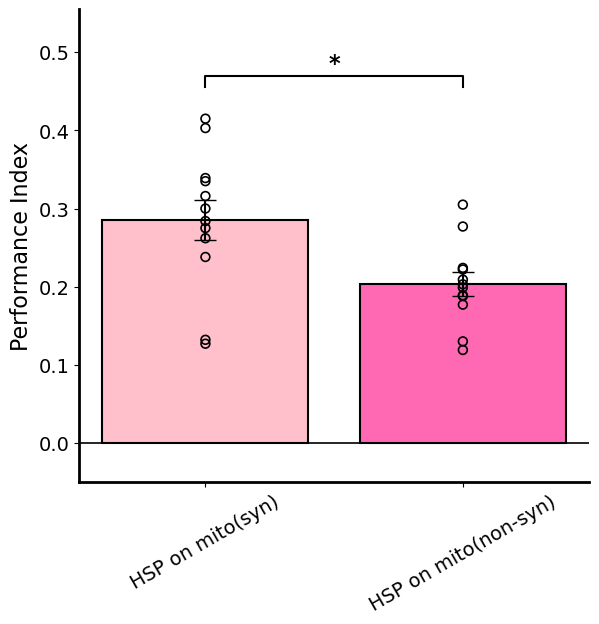

In [46]:
fast_plotter(['MB_syn_fraction of HSP in Mito','MB_non_syn_fraction of HSP in Mito'], df= df_raw, bar_color=["pink","hotpink"], labels=['HSP on mito(syn)','HSP on mito(non-syn)'] )

## Is the SNR-vs-colocalization correlation biology or a noise artifact? A calibration check

The Spearman correlation above shows SNR and odds ratio moving together, but that pattern is also exactly what **pure noise-driven attenuation toward the null** predicts, with zero real biological difference between brains (non-differential misclassification of both channel masks biases odds ratio/enrichment toward 1 as noise increases).

To get a noise-only reference, we take the sample with the best HSP/Mito SNR (the one we trust most), and progressively add synthetic Gaussian noise to its two channels, recomputing the same 95th-percentile mask -> odds ratio/enrichment pipeline at each noise level. Because the underlying true image never changes, any change across noise levels is coming from noise alone — this is what "colocalization" would look like if the true biology were held constant and only measurement noise varied.

We then interpolate each real brain's own SNR onto this noise-only curve to get `MB_total_odds_ratio_noise_null`: the odds ratio expected at that brain's SNR if it had the reference brain's true biology and its lower measured value were pure artifact. The ratio of the actual measured value to this expectation (`MB_total_odds_ratio_excess_ratio`):
- **~1** — fully consistent with noise-only attenuation; no evidence this brain differs biologically from the reference.
- **> 1** — more colocalization than noise alone would produce at that SNR — evidence of a real signal beyond the artifact.
- **< 1** — less colocalization than even pure noise would give — worth a closer look (could be a genuine biological difference, or an unrelated problem with that sample).

**Caveat:** this assumes every brain's true biology matches the reference brain and that lower-SNR brains are just "reference + more noise." That's a strong simplification (real brains differ in more than noise), so treat this as a lower bound / sanity check on how much noise alone can distort the metric, not a hard correction.

In [ ]:
np.random.seed(0)

def add_gaussian_noise(stack, sigma):
    if sigma == 0:
        return stack.astype(np.float32)
    return stack.astype(np.float32) + np.random.normal(0, sigma, size=stack.shape).astype(np.float32)

def coloc_stats(stack_A, stack_B, MASK, percentile=95):
    """Same odds-ratio/enrichment formulas as the main coloc cell, computed directly from raw stacks."""
    mask_A = (stack_A > np.percentile(stack_A, percentile)) & MASK
    mask_B = (stack_B > np.percentile(stack_B, percentile)) & MASK

    A_and_B = (mask_A & mask_B).sum()
    A_not_B = (mask_A & ~mask_B).sum()
    B_not_A = (~mask_A & mask_B).sum()
    neither = MASK.sum() - A_and_B - A_not_B - B_not_A

    odds_ratio, _ = fisher_exact([[A_and_B, A_not_B], [B_not_A, neither]], alternative='greater')

    pA = mask_A.sum() / MASK.sum()
    pB = mask_B.sum() / MASK.sum()
    expected = pA * pB * MASK.sum()
    enrichment = A_and_B / expected

    return odds_ratio, enrichment

# --- reference sample: the one with the best HSP/Mito SNR already in df ---
ref_name = df.sort_values('snr_min_HSP_Mito', ascending=False)['name'].iloc[0]
ref_series = series_list[list(info.keys()).index(ref_name)]
print(f'Calibrating on reference sample: {ref_name} (series {ref_series})')

ref_HSP  = results['s_' + str(ref_series)]['c_1'][deconv_str_mask]['stack'].astype(np.float32)
ref_Mito = results['s_' + str(ref_series)]['c_2'][deconv_str_mask]['stack'].astype(np.float32)
ref_MB   = results['s_' + str(ref_series)]['c_2'][deconv_str_mask]['mb'].astype(bool)

sigma0_HSP  = ref_HSP[ref_HSP <= np.median(ref_HSP)].std()
sigma0_Mito = ref_Mito[ref_Mito <= np.median(ref_Mito)].std()

# multiples of each channel's own background std, spanning down to the noisiest real sample's SNR
noise_levels = [0, 0.5, 1, 2, 3, 4, 6, 8, 12, 16, 24]

calib_rows = []
for k in noise_levels:
    noisy_HSP  = add_gaussian_noise(ref_HSP,  k * sigma0_HSP)
    noisy_Mito = add_gaussian_noise(ref_Mito, k * sigma0_Mito)

    snr_min_k = min(snr_proxy(noisy_HSP), snr_proxy(noisy_Mito))
    OR_k, enrich_k = coloc_stats(noisy_HSP, noisy_Mito, ref_MB)

    calib_rows.append({'noise_k': k, 'snr_min': snr_min_k, 'odds_ratio': OR_k, 'enrichment': enrich_k})

df_calib = pd.DataFrame(calib_rows).sort_values('snr_min').reset_index(drop=True)
print(df_calib)

# --- interpolate the noise-only curve onto each real sample's actual SNR ---
df['MB_total_odds_ratio_noise_null']   = np.interp(df['snr_min_HSP_Mito'], df_calib['snr_min'], df_calib['odds_ratio'])
df['MB_total_enrichment_noise_null']   = np.interp(df['snr_min_HSP_Mito'], df_calib['snr_min'], df_calib['enrichment'])
df['MB_total_odds_ratio_excess_ratio'] = df['MB_total_odds_ratio'] / df['MB_total_odds_ratio_noise_null']

df.to_csv(path_csv, index=False)
df[['name', 'snr_min_HSP_Mito', 'MB_total_odds_ratio', 'MB_total_odds_ratio_noise_null',
    'MB_total_odds_ratio_excess_ratio']].sort_values('snr_min_HSP_Mito', ascending=False)
